# 02. LangGraph 기본

## 학습 목표
- LangGraph의 핵심 개념(State, Node, Edge)을 이해한다
- `TypedDict`와 `add_messages`를 사용하여 State를 정의할 수 있다
- `StateGraph`로 기본 챗봇 그래프를 구성할 수 있다
- 그래프를 시각화하고 조건부 엣지를 활용할 수 있다

## 1. 환경 설정

In [9]:
from dotenv import load_dotenv
load_dotenv()

import os
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY가 .env 파일에 설정되어 있는지 확인하세요!"
print("환경 설정 완료!")

환경 설정 완료!


## 2. State 정의 (TypedDict + add_messages)

LangGraph에서 **State**는 그래프가 관리하는 데이터입니다.

- `TypedDict`: 상태의 구조를 정의
- `add_messages`: 메시지 리스트를 자동으로 누적해주는 리듀서(reducer)

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# State 정의
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지 누적 리듀서

# add_messages 동작 확인
# 기존 메시지 리스트에 새 메시지를 추가하면 누적됩니다
existing = [HumanMessage(content="안녕하세요")]
new = [AIMessage(content="안녕하세요! 무엇을 도와드릴까요?")]

result = add_messages(existing, new)
for msg in result:
    print(f"  [{msg.type}] {msg.content}")

  [human] 안녕하세요
  [ai] 안녕하세요! 무엇을 도와드릴까요?


## 3. Node 함수 만들기 (LLM 호출 노드)

Node는 그래프에서 실제 작업을 수행하는 함수입니다.

- 입력: 현재 State
- 출력: State 업데이트 (dict)

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")

# 챗봇 노드 함수
def chatbot(state: ChatState) -> dict:
    """현재 메시지를 기반으로 LLM 응답을 생성합니다."""
    response = llm.invoke(state["messages"])
    # add_messages 리듀서가 자동으로 기존 메시지에 추가합니다
    return {"messages": [response]}

print("chatbot 노드 함수 정의 완료!")
print(f"입력: ChatState (messages 리스트)")
print(f"출력: dict (새 메시지를 담은 messages 키)")

chatbot 노드 함수 정의 완료!
입력: ChatState (messages 리스트)
출력: dict (새 메시지를 담은 messages 키)


## 4. 기본 그래프 구성 (START -> chatbot -> END)

가장 간단한 그래프: 시작 -> 챗봇 노드 -> 종료

In [12]:
from langgraph.graph import StateGraph, START, END

# 1) 그래프 빌더 생성
graph_builder = StateGraph(ChatState)

# 2) 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 3) 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 -> 챗봇
graph_builder.add_edge("chatbot", END)     # 챗봇 -> 종료

# 4) 그래프 컴파일
graph = graph_builder.compile()

# 5) 실행
result = graph.invoke({
    "messages": [HumanMessage(content="LangGraph가 뭔지 한 문장으로 설명해줘")]
})

# 결과 출력
for msg in result["messages"]:
    print(f"[{msg.type}] {msg.content}")

[human] LangGraph가 뭔지 한 문장으로 설명해줘
[ai] LangGraph는 대형 언어 모델과 그래프 기반 지식 표현을 결합해 텍스트에서 개체와 관계를 추출하고 이를 구조화하여 검색·추론·지식 관리를 돕는 프레임워크입니다.


## 5. 그래프 시각화

그래프 구조를 ASCII와 Mermaid 다이어그램으로 시각화합니다.

=== ASCII 그래프 ===
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   



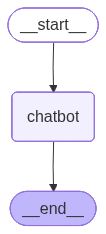

In [17]:
import importlib
import sys


def print_graph_ascii(compiled_graph) -> None:
    """grandalf 미설치·구버전 세션에서도 ASCII를 쓰도록 graph_ascii 모듈을 갱신합니다."""
    try:
        from grandalf.graphs import Vertex  # noqa: F401
        from grandalf.layouts import SugiyamaLayout  # noqa: F401
        from grandalf.routing import route_with_lines  # noqa: F401
    except ImportError:
        import subprocess

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "grandalf"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
    import langchain_core.runnables.graph_ascii as graph_ascii_mod

    importlib.reload(graph_ascii_mod)
    compiled_graph.get_graph().print_ascii()


# ASCII 시각화
print("=== ASCII 그래프 ===")
print_graph_ascii(graph)
print()

# Mermaid 다이어그램 (노트북에서 이미지로 표시)
try:
    from IPython.display import Image, display

    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f"Mermaid PNG 생성 실패 (네트워크·브라우저 등): {e}")
    print("대신 Mermaid 텍스트를 출력합니다:")
    print(graph.get_graph().draw_mermaid())

## 6. 조건부 엣지: 감정 분석 챗봇

사용자의 메시지 감정(긍정/부정)에 따라 다른 노드로 분기하는 그래프를 만들어봅시다.

```
START -> analyze_sentiment --긍정--> positive_response -> END
                           --부정--> negative_response -> END
```

In [18]:
from langchain_core.messages import SystemMessage

# State 정의 (감정 필드 추가)
class SentimentState(TypedDict):
    messages: Annotated[list, add_messages]
    sentiment: str  # "positive" 또는 "negative"

# 노드 1: 감정 분석
def analyze_sentiment(state: SentimentState) -> dict:
    """사용자 메시지의 감정을 분석합니다."""
    last_message = state["messages"][-1].content
    
    analysis_prompt = [
        SystemMessage(content="다음 텍스트의 감정을 분석하세요. 'positive' 또는 'negative' 중 하나만 답하세요."),
        HumanMessage(content=last_message)
    ]
    result = llm.invoke(analysis_prompt)
    sentiment = "positive" if "positive" in result.content.lower() else "negative"
    print(f"  [감정 분석] {sentiment}")
    return {"sentiment": sentiment}

# 노드 2: 긍정 응답
def positive_response(state: SentimentState) -> dict:
    """긍정적인 메시지에 대한 응답"""
    prompt_messages = [
        SystemMessage(content="사용자가 긍정적인 감정을 표현했습니다. 함께 기뻐하며 밝은 에너지로 응답하세요."),
        *state["messages"]
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}

# 노드 3: 부정 응답
def negative_response(state: SentimentState) -> dict:
    """부정적인 메시지에 대한 응답"""
    prompt_messages = [
        SystemMessage(content="사용자가 부정적인 감정을 표현했습니다. 공감하고 위로하며 따뜻하게 응답하세요."),
        *state["messages"]
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}

# 라우팅 함수
def route_by_sentiment(state: SentimentState) -> str:
    """감정에 따라 다음 노드를 결정합니다."""
    return "positive_response" if state["sentiment"] == "positive" else "negative_response"

# 그래프 구성
sentiment_builder = StateGraph(SentimentState)

# 노드 추가
sentiment_builder.add_node("analyze_sentiment", analyze_sentiment)
sentiment_builder.add_node("positive_response", positive_response)
sentiment_builder.add_node("negative_response", negative_response)

# 엣지 추가
sentiment_builder.add_edge(START, "analyze_sentiment")
sentiment_builder.add_conditional_edges(
    "analyze_sentiment",
    route_by_sentiment,
    {"positive_response": "positive_response", "negative_response": "negative_response"}
)
sentiment_builder.add_edge("positive_response", END)
sentiment_builder.add_edge("negative_response", END)

# 컴파일
sentiment_graph = sentiment_builder.compile()

# 시각화 (위쪽 시각화 셀의 print_graph_ascii가 있으면 재사용)
try:
    print_graph_ascii(sentiment_graph)
except NameError:
    import importlib
    import subprocess
    import sys

    try:
        from grandalf.graphs import Vertex  # noqa: F401
        from grandalf.layouts import SugiyamaLayout  # noqa: F401
        from grandalf.routing import route_with_lines  # noqa: F401
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "grandalf"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
    import langchain_core.runnables.graph_ascii as graph_ascii_mod

    importlib.reload(graph_ascii_mod)
    sentiment_graph.get_graph().print_ascii()

                    +-----------+                      
                    | __start__ |                      
                    +-----------+                      
                          *                            
                          *                            
                          *                            
                +-------------------+                  
                | analyze_sentiment |                  
                +-------------------+                  
                  ..              ..                   
               ...                  ...                
             ..                        ..              
+-------------------+           +-------------------+  
| negative_response |           | positive_response |  
+-------------------+           +-------------------+  
                  **              **                   
                    ***        ***                     
                       **    **                 

In [ ]:
# 테스트: 긍정적인 메시지
print("=== 긍정 테스트 ===")
result = sentiment_graph.invoke({
    "messages": [HumanMessage(content="오늘 시험에 합격했어요! 너무 기뻐요!")],
    "sentiment": ""
})
print(f"응답: {result['messages'][-1].content}")
print()

# 테스트: 부정적인 메시지
print("=== 부정 테스트 ===")
result = sentiment_graph.invoke({
    "messages": [HumanMessage(content="프로젝트 발표를 망쳤어요. 너무 속상합니다.")],
    "sentiment": ""
})
print(f"응답: {result['messages'][-1].content}")

## 7. 실습 과제: 문서 분류 워크플로우 만들기

사용자가 입력한 텍스트를 분류하고, 카테고리에 따라 다른 처리를 하는 그래프를 만드세요.

### 요구사항
1. `classify` 노드: LLM으로 텍스트를 3개 카테고리 중 하나로 분류 (예: 기술, 비즈니스, 일상)
2. 각 카테고리별 처리 노드: 분류 결과에 따라 다른 스타일로 요약/응답
3. 조건부 엣지로 연결
4. 그래프 시각화
5. 최소 3개 테스트 메시지로 검증

In [23]:
# --- 1) State 정의 ---
class DocWorkflowState(TypedDict):
    messages: Annotated[list, add_messages]
    category: str  # "tech" | "business" | "daily"
    classification_comment: str  # 왜 해당 카테고리로 분류했는지 (LLM 설명)


_CATEGORY_KO = {"tech": "기술", "business": "비즈니스", "daily": "일상"}


def _normalize_category(llm_text: str) -> str:
    s = (llm_text or "").strip().lower()
    raw = llm_text or ""
    if "기술" in raw or "tech" in s:
        return "tech"
    if "비즈니스" in raw or "비지니스" in raw or "business" in s:
        return "business"
    return "daily"


# --- 2) 노드 함수 정의 ---
import json
import re


def classify(state: DocWorkflowState) -> dict:
    """LLM으로 텍스트를 기술 / 비즈니스 / 일상 중 하나로 분류하고, 근거를 짧게 남깁니다."""
    last = state["messages"][-1].content
    prompt = [
        SystemMessage(
            content=(
                "사용자 텍스트의 주제를 분류하세요. 반드시 JSON 객체 한 개만 출력하세요(앞뒤 설명 금지).\n"
                '키: "category" — 값은 반드시 "기술", "비즈니스", "일상" 중 하나(한글 정확히).\n'
                '키: "reason" — 왜 그 카테고리인지 한국어로 1~3문장으로 간단히.\n'
                "예: {\"category\": \"기술\", \"reason\": \"프로그래밍 언어 메모리 모델을 묻고 있어 기술 주제로 판단했습니다.\"}"
            )
        ),
        HumanMessage(content=last),
    ]
    raw = llm.invoke(prompt).content.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE)
        raw = re.sub(r"\s*```\s*$", "", raw)
    comment = ""
    cat_raw = ""
    try:
        data = json.loads(raw)
        cat_raw = str(data.get("category", "")).strip()
        comment = str(data.get("reason", "")).strip()
    except json.JSONDecodeError:
        cat_raw = raw
        comment = "모델 응답을 JSON으로 파싱하지 못해, 응답 전체에서 카테고리만 추정했습니다."
    cat = _normalize_category(cat_raw)
    if not comment:
        comment = "분류 근거가 비어 있습니다."
    print(
        f"  [분류] {_CATEGORY_KO.get(cat, cat)} ← 모델 category: {cat_raw!r}"
    )
    return {"category": cat, "classification_comment": comment}


def handle_tech(state: DocWorkflowState) -> dict:
    """기술 주제: 용어·구조를 바르게 짚고, 질문이 짧게 답해 달라고 하지 않는 한 불필요하게 압축하지 않습니다."""
    msgs = [
        SystemMessage(
            content="당신은 기술 문서 도우미입니다. 정확한 용어로 설명하고, 필요하면 단계·예시·주의할 점까지 질문에 맞게 충분히 답하세요. "
            "사용자가 '한 문장' 등으로 길이를 명시한 경우에만 그 제한을 따릅니다."
        ),
        *state["messages"],
    ]
    reply = llm.invoke(msgs)
    return {"messages": [reply]}


def handle_business(state: DocWorkflowState) -> dict:
    """비즈니스 주제: 실무 관점에서 충분한 근거와 실행 아이디어를 담아 응답합니다."""
    msgs = [
        SystemMessage(
            content="당신은 비즈니스 코치입니다. 가치 제안, 리스크, 액션 아이템을 실무적으로 정리하되, "
            "핵심을 잘라내어 과도하게 짧게 만들지 마세요. 필요한 목록·소목록은 유지하세요."
        ),
        *state["messages"],
    ]
    reply = llm.invoke(msgs)
    return {"messages": [reply]}


def handle_daily(state: DocWorkflowState) -> dict:
    """일상 주제: 친근한 톤으로, 추천·설명은 질문에 걸맞게 충분히 적습니다."""
    msgs = [
        SystemMessage(
            content="당신은 친구 같은 대화 상대입니다. 공감하며 일상적인 말투로 답하되, "
            "추천이나 설명이 필요한 질문이면 단답으로 끊지 말고 필요한 만큼 풀어서 답하세요."
        ),
        *state["messages"],
    ]
    reply = llm.invoke(msgs)
    return {"messages": [reply]}


# --- 3) 라우팅 함수 정의 ---
def route_by_category(state: DocWorkflowState) -> str:
    c = state.get("category") or "daily"
    return {
        "tech": "handle_tech",
        "business": "handle_business",
        "daily": "handle_daily",
    }.get(c, "handle_daily")


# --- 4) 그래프 구성 및 컴파일 ---
doc_workflow_builder = StateGraph(DocWorkflowState)
doc_workflow_builder.add_node("classify", classify)
doc_workflow_builder.add_node("handle_tech", handle_tech)
doc_workflow_builder.add_node("handle_business", handle_business)
doc_workflow_builder.add_node("handle_daily", handle_daily)

doc_workflow_builder.add_edge(START, "classify")
doc_workflow_builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "handle_tech": "handle_tech",
        "handle_business": "handle_business",
        "handle_daily": "handle_daily",
    },
)
doc_workflow_builder.add_edge("handle_tech", END)
doc_workflow_builder.add_edge("handle_business", END)
doc_workflow_builder.add_edge("handle_daily", END)

doc_workflow = doc_workflow_builder.compile()

# --- 5) 시각화 ---
print("=== 문서 분류 워크플로우 (ASCII) ===")
try:
    print_graph_ascii(doc_workflow)
except NameError:
    import importlib
    import subprocess
    import sys

    try:
        from grandalf.graphs import Vertex  # noqa: F401
        from grandalf.layouts import SugiyamaLayout  # noqa: F401
        from grandalf.routing import route_with_lines  # noqa: F401
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "grandalf"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
    import langchain_core.runnables.graph_ascii as graph_ascii_mod

    importlib.reload(graph_ascii_mod)
    doc_workflow.get_graph().print_ascii()
print()

# --- 6) 테스트 (카테고리별 3건) ---
test_cases = [
    (
        "기술",
        "Rust의 소유권(ownership)이 메모리 안전에 어떻게 기여하는지, 개념과 빌림 규칙을 짧은 예시와 함께 설명해 줘.",
    ),
    (
        "비즈니스",
        "스타트업이 시드 라운드에서 투자자에게 강조해야 할 재무 지표 세 가지를 제안해 줘.",
    ),
    (
        "일상",
        "주말에 비 온 뒤 산책하기 좋은 카페 근처 코스 추천해 줘.",
    ),
]

# 긴 print()를 한 줄로 이어 쓰면 Cursor/VS Code 노트북이 앞부분 stdout을 접어 ... 로 보일 수 있어,
# 테스트마다 display(HTML)로 별도 출력 블록을 만듭니다.
try:
    from IPython.display import display, HTML
except ImportError:  # 스크립트 실행 시
    display = None  # type: ignore[assignment]
    HTML = None  # type: ignore[assignment]

import html as html_module

results: list[tuple[str, str, dict]] = []
for label, user_text in test_cases:
    out = doc_workflow.invoke(
        {
            "messages": [HumanMessage(content=user_text)],
            "category": "",
            "classification_comment": "",
        }
    )
    results.append((label, user_text, out))

for label, user_text, out in results:
    final_text = out["messages"][-1].content
    cat_key = out.get("category") or ""
    cat_ko = _CATEGORY_KO.get(cat_key, cat_key)
    reason = (out.get("classification_comment") or "").strip()
    if display is not None and HTML is not None:
        block = HTML(
            "<div style='margin:1rem 0;padding:12px;border:1px solid #555;border-radius:8px;max-height:none;overflow:visible'>"
            f"<h3 style='margin-top:0'>테스트: {html_module.escape(label)}</h3>"
            "<p><b>사용자</b></p>"
            f"<pre style='white-space:pre-wrap;margin:0 0 8px 0'>{html_module.escape(user_text)}</pre>"
            "<p style='margin:8px 0 4px 0'><b>분류</b></p>"
            f"<p style='margin:0 0 6px 0'>{html_module.escape(cat_ko)} "
            f"<span style='color:#888'>(상태 키: {html_module.escape(cat_key)})</span></p>"
            "<p style='margin:0 0 4px 0'><b>왜 이 카테고리인지</b></p>"
            f"<pre style='white-space:pre-wrap;margin:0 0 12px 0;font-size:0.9em;background:#f5f5f5;padding:8px;border-radius:6px'>{html_module.escape(reason)}</pre>"
            f"<p style='margin:0 0 4px 0'><b>최종 응답</b> ({len(final_text)}자)</p>"
            f"<pre style='white-space:pre-wrap;margin:0;font-size:0.92em'>{html_module.escape(final_text)}</pre>"
            "</div>"
        )
        display(block)
    else:
        print(f"========== 테스트: {label} ==========")
        print(f"사용자: {user_text}")
        print(f"분류: {cat_ko} ({cat_key})")
        print(f"분류 코멘트: {reason}")
        print(f"응답 ({len(final_text)}자):")
        print(final_text)
        print()


=== 문서 분류 워크플로우 (ASCII) ===
                              +-----------+                              
                              | __start__ |                              
                              +-----------+                              
                                     *                                   
                                     *                                   
                                     *                                   
                               +----------+                              
                              .| classify |..                            
                          .... +----------+  ....                        
                     .....           .           .....                   
                 ....                 .               ....               
              ...                     .                   ...            
+-----------------+           +--------------+           +-------------+ 
| handle_b